## 11.06节练习参考答案

## 环境准备

In [2]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import math

from src.utils import *

本节的解答思路参考了 [《动手学深度学习》习题解答](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/ch11/ch11)。

### 练习11.6.1
使用动量超参数和学习率的其他组合，观察和分析不同的实验结果。

**解答：**

In [3]:
def init_momentum_states(feature_dim):
    v_w = torch.zeros((feature_dim, 1))
    v_b = torch.zeros(1)
    return (v_w, v_b)

def sgd_momentum(params, states, hyperparams):
    for p, v in zip(params, states):
        with torch.no_grad():
            v[:] = hyperparams['momentum'] * v + p.grad
            p[:] -= hyperparams['lr'] * v
        p.grad.data.zero_()

def train_momentum(lr, momentum, num_epochs=2):
    train_ch11(sgd_momentum, init_momentum_states(feature_dim),
                   {'lr': lr, 'momentum': momentum}, data_iter,
                   feature_dim, num_epochs)

data_iter, feature_dim = get_data_ch11(batch_size=10)

loss: 0.243, 0.009 sec/epoch


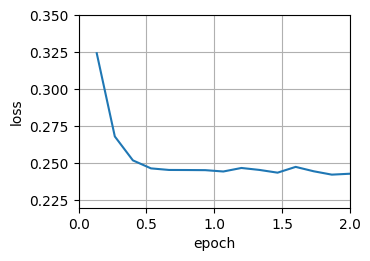

In [4]:
train_momentum(lr=0.02, momentum=0.5)

loss: 0.246, 0.009 sec/epoch


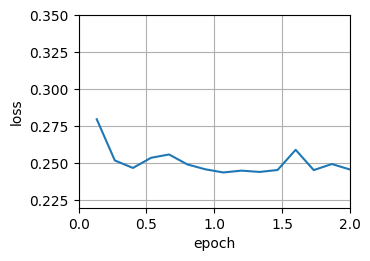

In [5]:
train_momentum(lr=0.01, momentum=0.9)

### 练习11.6.2
试试梯度下降和动量法来解决一个二次问题，其中有多个特征值，即$f(x) = \frac{1}{2} \sum_i \lambda_i x_i^2$，例如$\lambda_i = 2^{-i}$。绘制出$x$的值在初始化$x_i = 1$时如何下降。

**解答：**

In [8]:
def quadratic_function(x):
    feature_dim = x.shape[0]
    lambdas = torch.tensor([2**(-i) for i in range(1, feature_dim+1)])
    return 0.5 * torch.sum(lambdas * x**2)

def compute_gradient(x):
    feature_dim = x.shape[0]
    lambdas = torch.tensor([2**(-i) for i in range(1, feature_dim+1)])
    return lambdas * x

def sgd_quadratic(params, states, hyperparams):
    lr = hyperparams['lr']
    with torch.no_grad():
        params -= lr * compute_gradient(params)

def init_momentum_states_quadratic(feature_dim):
    v = torch.zeros(feature_dim)
    return v

def sgd_momentum_quadratic(params, states, hyperparams):
    lr = hyperparams['lr']
    momentum = hyperparams['momentum']
    with torch.no_grad():
        states[:] = momentum * states + compute_gradient(params)
        params -= lr * states

def train(optimizer, lr, momentum, num_epochs=10, mom=True):
    feature_dim = 10  # 设置特征维度为10，可以根据实际情况进行调整
    params = torch.ones(feature_dim, requires_grad=True)
    if mom:
        states = init_momentum_states_quadratic(feature_dim)
    else:
        states = torch.zeros_like(params)

    x_values = []

    for epoch in range(num_epochs):
        loss = quadratic_function(params)
        loss.backward()
        optimizer(params, states, {'lr': lr, 'momentum': momentum})
        params.grad.data.zero_()

        x_values.append(params.clone().detach().numpy())

    return x_values

# 使用SGD进行训练
lr = 0.1
momentum = 0.9
x_values_sgd = train(sgd_quadratic, lr, momentum)

# 使用带动量的SGD进行训练
x_values_momentum = train(sgd_momentum_quadratic, lr, momentum)

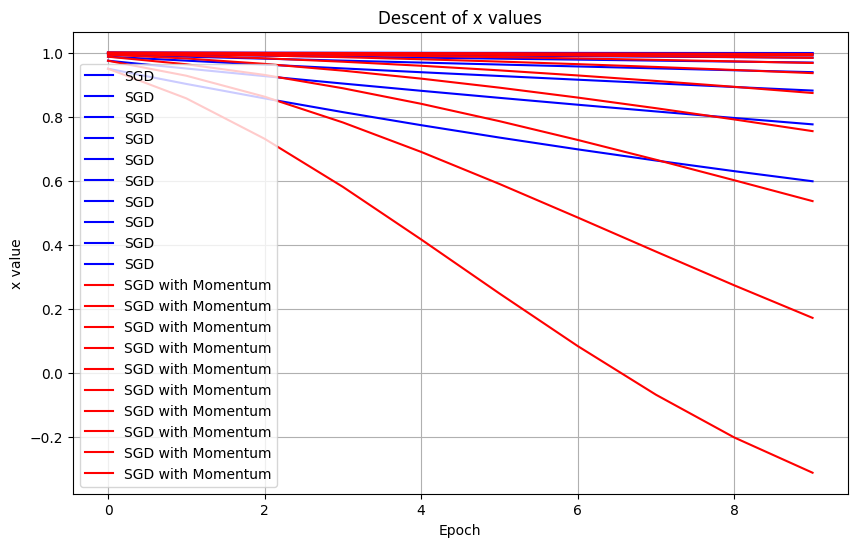

In [9]:
# 绘制x值的下降情况
plt.figure(figsize=(10, 6))
plt.plot(x_values_sgd, label='SGD', color='blue')
plt.plot(x_values_momentum, label='SGD with Momentum', color='red')
plt.xlabel('Epoch')
plt.ylabel('x value')
plt.title('Descent of x values')
plt.legend()
plt.grid(True)
plt.show()

### 练习11.6.3
推导$h(\mathbf{x}) = \frac{1}{2} \mathbf{x}^\top \mathbf{Q} \mathbf{x} + \mathbf{x}^\top \mathbf{c} + b$的最小值和最小化器。

**解答：**

$$
h(\boldsymbol{x})=\frac12\boldsymbol{x}^\mathrm{T}\boldsymbol{Q}\boldsymbol{x}+\boldsymbol{x}^\mathrm{T}\boldsymbol{c}+b.
$$

这是一个普通的二次函数。对于正定矩阵 $\boldsymbol{Q}\succ 0$，即对于具有正特征值的矩阵，有

最小化器为 $\boldsymbol{x}^*=-\boldsymbol{Q}^{-1}\boldsymbol{c}$，最小值为 $b-\frac12\boldsymbol{c}^\mathrm{T}\boldsymbol{Q}^{-1}\boldsymbol{c}$。

证明如下： 给定函数：
$$
h(\boldsymbol{x})=\frac12\boldsymbol{x}^\mathrm{T}\boldsymbol{Q}\boldsymbol{x}+\boldsymbol{x}^\mathrm{T}\boldsymbol{c}+b
$$

其中，$\boldsymbol{x}\in\mathbb{R}^n$，$\boldsymbol{Q}$ 是一个 $n\times n$ 的正定矩阵，$\boldsymbol{c}\in\mathbb{R}^n$，$b$ 是一个实数。

求解步骤：

**Step 1: 求梯度**

首先计算 $h(\boldsymbol{x})$ 对 $\boldsymbol{x}$ 的梯度：
$$
\nabla h(\boldsymbol{x})=\nabla\left(\frac12\boldsymbol{x}^\mathrm{T}\boldsymbol{Q}\boldsymbol{x}+\boldsymbol{x}^\mathrm{T}\boldsymbol{c}+b\right)=\frac12(\boldsymbol{Q}+\boldsymbol{Q}^\mathrm{T})\boldsymbol{x}+\boldsymbol{c}.
$$

由于 $\boldsymbol{Q}$ 是对称矩阵，所以 $\boldsymbol{Q}+\boldsymbol{Q}^\mathrm{T}=2\boldsymbol{Q}$。

因此，梯度可以简化为：
$$
\nabla h(\boldsymbol{x})=\boldsymbol{Q}\boldsymbol{x}+\boldsymbol{c}.
$$

**Step 2: 解析解**

要找到使梯度为零的 $\boldsymbol{x}$，我们解以下方程：
$$
\boldsymbol{Q}\boldsymbol{x}+\boldsymbol{c}=0.
$$

解得最小化器为：
$$
\boldsymbol{x}^* = -\boldsymbol{Q}^{-1}\boldsymbol{c}.
$$

这给出了使 $h(\boldsymbol{x})$ 取得最小值的临界点。

**Step 3: 计算最小值**

将临界点 $\boldsymbol{x}^* = -\boldsymbol{Q}^{-1}\boldsymbol{c}$ 代入 $h(\boldsymbol{x})$：
$$
h(\boldsymbol{x}^*) = \frac12\left(-\boldsymbol{Q}^{-1}\boldsymbol{c}\right)^\mathrm{T}\boldsymbol{Q}\left(-\boldsymbol{Q}^{-1}\boldsymbol{c}\right)+\left(-\boldsymbol{Q}^{-1}\boldsymbol{c}\right)^\mathrm{T}\boldsymbol{c}+b.
$$

经过推导和化简，我们得到最小值为：
$$
h(\boldsymbol{x}^*) = b-\frac12\boldsymbol{c}^\mathrm{T}\boldsymbol{Q}^{-1}\boldsymbol{c}.
$$

以上是对给定函数中最小化器和最小值的证明。

### 练习11.6.4
当我们执行带动量法的随机梯度下降时会有什么变化？当我们使用带动量法的小批量随机梯度下降时会发生什么？试验参数如何？

**解答：**

In [13]:
def train_sgd(lr, batch_size, num_epochs=2):
    data_iter, feature_dim = get_data_ch11(batch_size)
    return train_ch11(
        sgd, None, {'lr': lr}, data_iter, feature_dim, num_epochs)

def train_momentum(lr, momentum, num_epochs=2):
    train_ch11(sgd_momentum, init_momentum_states(feature_dim),
                   {'lr': lr, 'momentum': momentum}, data_iter,
                   feature_dim, num_epochs)

def train_momentum_mini_sgd(lr, batch_size, momentum, num_epochs=2):
    data_iter, feature_dim = get_data_ch11(batch_size)
    return train_ch11(sgd_momentum, init_momentum_states(feature_dim),
                   {'lr': lr, 'momentum': momentum}, data_iter,
                   feature_dim, num_epochs)

loss: 0.245, 0.003 sec/epoch


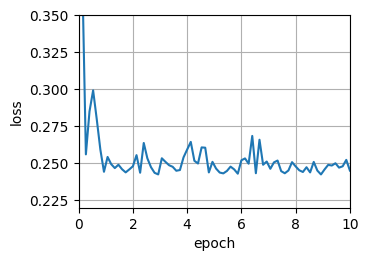

In [14]:
train_momentum_mini_sgd(lr=0.05, batch_size=50, momentum=0.9 ,num_epochs=10);


loss: 0.244, 0.072 sec/epoch


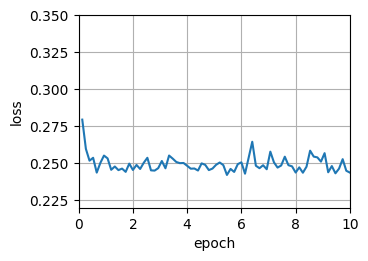

In [15]:
train_momentum_mini_sgd(lr=0.001, batch_size=1, momentum=0.9 ,num_epochs=10);
